# 02 - Baselines: TF-IDF (Logistic Regression, Ridge) and fastText
Both baselines use the shared cleaned text and the fixed split from `src/preprocessing.py`.
All tuning uses the **validation** split (selection metric: macro-F1, RMSE reported alongside); each chosen model is evaluated **once** on the **test** split.
Every run is appended to `reports/experiment_log.csv`.

| Exp | Question | Varied | Fixed |
|---|---|---|---|
| B1 | Does the shared cleaning help a bag-of-words model? | raw `safe_text` vs `clean_text` | LogReg, word 1-2 grams, C=1 |
| B2 | Which text representation works best? | word 1-gram, word 1-2, char 2-5, word+char; C | LogReg, balanced |
| B3 | Does class weighting help the minority (negative) class? | balanced vs none | best B2 setting |
| B4 | Classification head vs regression head (RMSE is the Zindi metric) | Ridge regression; alpha | best B2 features |
| B5 | How much data does the baseline need? | training-set size 10-100% | best LogReg |
| F1 | fastText hyperparameters | lr, epoch, wordNgrams, dim | softmax, minCount 2 |
| F2 | fastText training length | epochs 1-50 | best F1 setting |

**Before running:** put `Train.csv` in `data/raw/`. The split is created automatically if it does not exist yet.

In [1]:
%pip install -q emoji fasttext-wheel wordcloud

import os, sys

# Colab: mount Drive and use the project folder there. Local: use the repo root.
if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE = "/content/drive/MyDrive/formative2-vaccine-sentiment"
else:
    BASE = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()

for d in ["data/raw", "data/processed", "reports/figures", "reports/predictions"]:
    os.makedirs(os.path.join(BASE, d), exist_ok=True)
os.chdir(BASE)
sys.path.insert(0, BASE)
print("Working directory:", os.getcwd())

Note: you may need to restart the kernel to use updated packages.
Working directory: C:\Users\hb\formative2-vaccine-sentiment


C:\Users\hb\formative2-vaccine-sentiment\.venv\Scripts\python.exe: No module named pip


## Data

In [2]:
import itertools
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import recall_score
from sklearn.utils.class_weight import compute_sample_weight
from src.preprocessing import make_splits, load_splits
from src.evaluation import evaluate, save_predictions, log_run, score

sns.set_theme(style="whitegrid")
FIG = "reports/figures/"
AUTHOR = "P1"

if not os.path.exists("data/processed/train.csv"):
    make_splits()
train, val, test = load_splits()
print(train.shape, val.shape, test.shape)

(6689, 6) (1433, 6) (1434, 6)


## Helpers
- **Features.** `word12` = word 1-2 grams; `char25` = character 2-5 grams inside word boundaries (robust to misspellings and the long tail of rare words found in the EDA); `word+char` = both stacked.
- **Logistic Regression** gives class probabilities; its continuous score for RMSE is the expected label $\sum_k p_k\,k$.
- **Ridge** regresses the label directly; the score is clipped to [-1, 1] and rounded to a class.

In [3]:
FEATURES = {
    "word1":     [dict(analyzer="word", ngram_range=(1, 1))],
    "word12":    [dict(analyzer="word", ngram_range=(1, 2))],
    "char25":    [dict(analyzer="char_wb", ngram_range=(2, 5))],
    "word+char": [dict(analyzer="word", ngram_range=(1, 2)), dict(analyzer="char_wb", ngram_range=(2, 5))],
}

class Featurizer:
    def __init__(self, kind):
        self.vecs = [TfidfVectorizer(min_df=2, sublinear_tf=True, **kw) for kw in FEATURES[kind]]
    def fit_transform(self, texts):
        return hstack([v.fit_transform(texts) for v in self.vecs]).tocsr()
    def transform(self, texts):
        return hstack([v.transform(texts) for v in self.vecs]).tocsr()

def predict_out(model, X):
    if isinstance(model, Ridge):
        s = np.clip(model.predict(X), -1, 1)
        return np.clip(np.round(s), -1, 1).astype(int), s
    proba = model.predict_proba(X)
    return model.classes_[proba.argmax(1)], proba @ model.classes_

def run(name, features, model, text_col="clean_text", weight=None, tr=None, log=True, **params):
    # Fit on train (or subset tr), score on val, log the run. Returns (f1, rmse, featurizer, model).
    tr = train if tr is None else tr
    fz = Featurizer(features)
    Xtr, Xva = fz.fit_transform(tr[text_col]), fz.transform(val[text_col])
    sw = compute_sample_weight("balanced", tr["label"]) if weight == "balanced" else None
    model.fit(Xtr, tr["label"], sample_weight=sw)
    yp, ys = predict_out(model, Xva)
    f1, rmse = score(val["label"], yp, ys)
    if log:
        log_run(name, dict(features=features, text=text_col, weight=weight, **params), f1, rmse, author=AUTHOR)
    return f1, rmse, fz, model

def logreg(C): return LogisticRegression(C=C, max_iter=3000)

## B1: preprocessing ablation (raw vs cleaned text)

In [4]:
b1 = []
for col in ["safe_text", "clean_text"]:
    f1, rmse, *_ = run("tfidf_logreg", "word12", logreg(1), text_col=col, weight="balanced", C=1, exp="B1")
    b1.append(dict(text=col, val_macro_f1=f1, val_rmse=rmse))
display(pd.DataFrame(b1).round(4))

,text,val_macro_f1,val_rmse
0,safe_text,0.6423,0.6045
1,clean_text,0.6380,0.6070


*Interpretation:* cleaning makes almost no difference to a bag-of-words model (macro-F1 0.642 raw vs 0.638 cleaned, RMSE 0.605 vs 0.607; a 0.004 gap is smaller than the ±0.008 seed variation seen in B5). TF-IDF with `min_df=2` already down-weights the `<user>`/`<url>` placeholders, so we keep the shared cleaning for consistency with the neural models (which need a smaller, normalised vocabulary) rather than for a gain here.

## B2: text representation x regularisation (Logistic Regression, balanced)

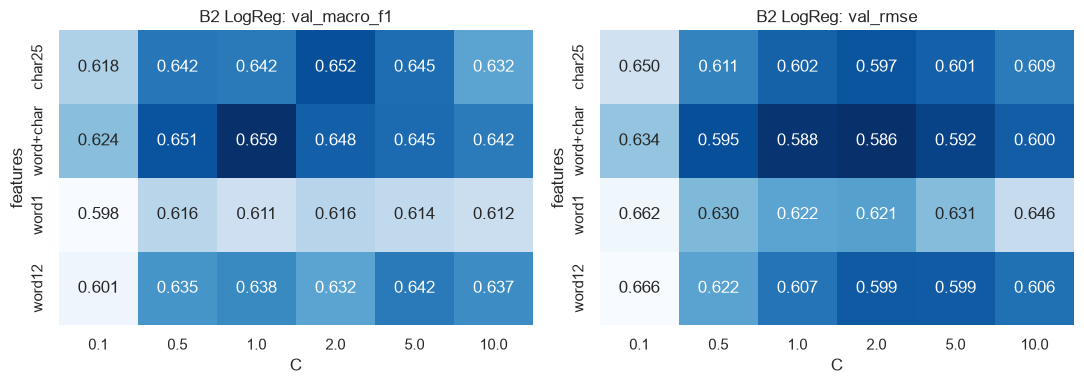

Best B2: {'features': 'word+char', 'C': 1.0, 'val_macro_f1': 0.6590090314010513, 'val_rmse': 0.5875202389338179}


In [5]:
b2 = []
for feat, C in itertools.product(FEATURES, [0.1, 0.5, 1, 2, 5, 10]):
    f1, rmse, *_ = run("tfidf_logreg", feat, logreg(C), weight="balanced", C=C, exp="B2")
    b2.append(dict(features=feat, C=C, val_macro_f1=f1, val_rmse=rmse))
b2 = pd.DataFrame(b2)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, m in zip(axes, ["val_macro_f1", "val_rmse"]):
    sns.heatmap(b2.pivot(index="features", columns="C", values=m), annot=True, fmt=".3f",
                cmap="Blues" if m == "val_macro_f1" else "Blues_r", cbar=False, ax=ax)
    ax.set_title(f"B2 LogReg: {m}")
plt.tight_layout(); plt.savefig(FIG + "b2_logreg_grid.png", dpi=200); plt.show()

best_lr = b2.loc[b2["val_macro_f1"].idxmax()]
print("Best B2:", best_lr.to_dict())

## B3: class weighting

In [6]:
b3 = []
for w in [None, "balanced"]:
    fz = Featurizer(best_lr["features"])
    Xtr, Xva = fz.fit_transform(train["clean_text"]), fz.transform(val["clean_text"])
    sw = compute_sample_weight("balanced", train["label"]) if w else None
    m = logreg(best_lr["C"]).fit(Xtr, train["label"], sample_weight=sw)
    yp, ys = predict_out(m, Xva)
    f1, rmse = score(val["label"], yp, ys)
    log_run("tfidf_logreg", dict(features=best_lr["features"], C=best_lr["C"], weight=w, exp="B3"), f1, rmse, author=AUTHOR)
    rec = recall_score(val["label"], yp, labels=[-1, 0, 1], average=None)
    b3.append(dict(weight=str(w), val_macro_f1=f1, val_rmse=rmse,
                   recall_neg=rec[0], recall_neu=rec[1], recall_pos=rec[2]))
display(pd.DataFrame(b3).round(4))
best_weight = "balanced" if b3[1]["val_macro_f1"] >= b3[0]["val_macro_f1"] else None

,weight,val_macro_f1,val_rmse,recall_neg,recall_neu,recall_pos
0,None,0.6404,0.5631,0.2810,0.7977,0.7874
1,balanced,0.6590,0.5875,0.5294,0.7673,0.7245


*Interpretation:* class weighting trades RMSE for minority-class recall. Without it the model almost ignores negative tweets (recall 0.28) but gets a lower RMSE (0.563), because predicting the frequent neutral/positive classes keeps squared errors small. Balanced weights nearly double negative recall (0.53) and raise macro-F1 from 0.640 to 0.659, at a cost of +0.024 RMSE. We select on macro-F1 because detecting anti-vaccine stance is the practically important case.

## B4: regression head (Ridge)

In [7]:
b4 = []
for feat, a in itertools.product(FEATURES, [0.5, 1, 2, 5, 10]):
    for w in [None, "balanced"]:
        f1, rmse, *_ = run("tfidf_ridge", feat, Ridge(alpha=a), weight=w, alpha=a, exp="B4")
        b4.append(dict(features=feat, alpha=a, weight=str(w), val_macro_f1=f1, val_rmse=rmse))
b4 = pd.DataFrame(b4)
display(b4.sort_values("val_macro_f1", ascending=False).head(8).round(4))
display(b4.sort_values("val_rmse").head(5).round(4))
best_ridge = b4.loc[b4["val_macro_f1"].idxmax()]
print("Best Ridge (by macro-F1):", best_ridge.to_dict())

,features,alpha,weight,val_macro_f1,val_rmse
32,word+char,1.0,None,0.5133,0.5875
31,word+char,0.5,balanced,0.5126,0.6252
20,char25,0.5,None,0.5120,0.5907
30,word+char,0.5,None,0.5110,0.6039
10,word12,0.5,None,0.5102,0.6027
34,word+char,2.0,None,0.5099,0.5765
33,word+char,1.0,balanced,0.5083,0.6142
21,char25,0.5,balanced,0.5074,0.6335


,features,alpha,weight,val_macro_f1,val_rmse
36,word+char,5.0,None,0.4812,0.5725
24,char25,2.0,None,0.4950,0.5743
26,char25,5.0,None,0.4710,0.5759
34,word+char,2.0,None,0.5099,0.5765
38,word+char,10.0,None,0.4604,0.5765


Best Ridge (by macro-F1): {'features': 'word+char', 'alpha': 1.0, 'weight': 'None', 'val_macro_f1': 0.5133480391348476, 'val_rmse': 0.5874546641322185}


*Interpretation:* the regression head reaches a similar RMSE to Logistic Regression (best 0.573 vs 0.563 unweighted) but a much lower macro-F1 (≤0.51). Regressing to the label mean pulls scores towards 0, so rounding collapses most tweets into neutral and almost never reaches -1 (negative recall 0.13 on test). RMSE and macro-F1 therefore reward different behaviour, which is why we report both and treat the label as ordinal-but-categorical for classification.

## Final test evaluation of both TF-IDF baselines

== tfidf_logreg | RMSE 0.5838 ==
              precision    recall  f1-score   support

    negative      0.415     0.526     0.464       152
     neutral      0.824     0.762     0.792       693
    positive      0.703     0.716     0.710       589

    accuracy                          0.718      1434
   macro avg      0.647     0.668     0.655      1434
weighted avg      0.731     0.718     0.723      1434



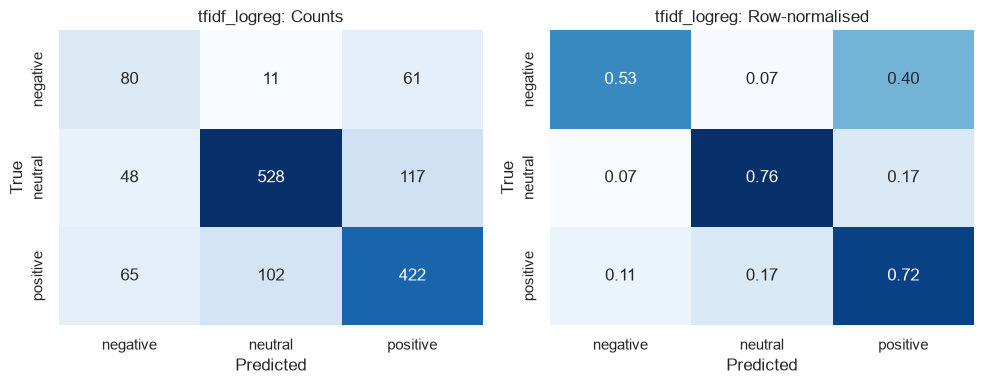

== tfidf_ridge | RMSE 0.5844 ==
              precision    recall  f1-score   support

    negative      0.606     0.132     0.216       152
     neutral      0.608     0.851     0.709       693
    positive      0.730     0.533     0.616       589

    accuracy                          0.644      1434
   macro avg      0.648     0.505     0.514      1434
weighted avg      0.658     0.644     0.619      1434



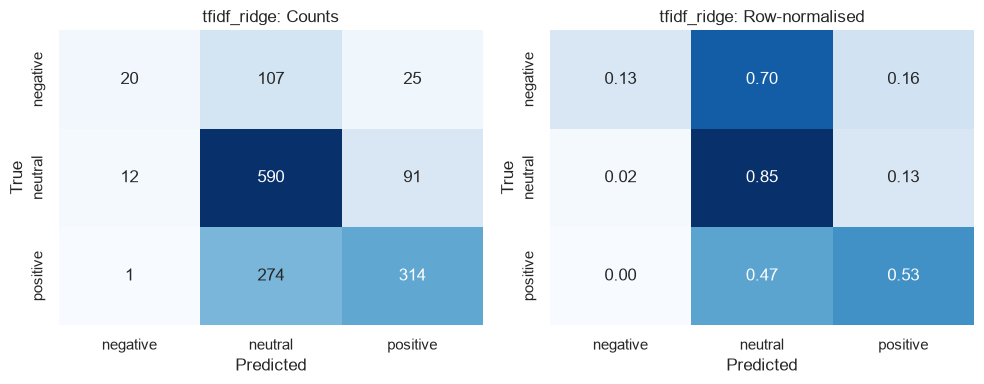

In [8]:
def fit_final(features, model, weight):
    fz = Featurizer(features)
    sw = compute_sample_weight("balanced", train["label"]) if weight in ("balanced",) else None
    model.fit(fz.fit_transform(train["clean_text"]), train["label"], sample_weight=sw)
    return fz, model

fz_lr, m_lr = fit_final(best_lr["features"], logreg(best_lr["C"]), best_weight)
fz_rg, m_rg = fit_final(best_ridge["features"], Ridge(alpha=best_ridge["alpha"]), best_ridge["weight"])

for name, fz, m in [("tfidf_logreg", fz_lr, m_lr), ("tfidf_ridge", fz_rg, m_rg)]:
    yp, ys = predict_out(m, fz.transform(test["clean_text"]))
    evaluate(test["label"], yp, name, y_score=ys)
    save_predictions(name, test["tweet_id"], test["safe_text"], test["label"], yp, test["agreement"], ys)

## What the linear model learned
Largest positive coefficients for the negative and positive classes (word features only), as evidence of which cues a bag-of-n-grams model relies on.

In [9]:
fz_w, m_w = fit_final("word12", logreg(best_lr["C"]), best_weight)
vocab = fz_w.vecs[0].get_feature_names_out()
rows = {}
for k, cls in enumerate(m_w.classes_):
    top = np.argsort(m_w.coef_[k])[::-1][:15]
    rows[{-1: "negative", 0: "neutral", 1: "positive"}[cls]] = vocab[top]
display(pd.DataFrame(rows))

,negative,neutral,positive
0,cdcwhistleblower,measles,vaccinate
1,vaccines,mmr,vaccineswork
2,autism,immunity,kids
3,vaccine,the measles,anti
4,vaccinations,disneyland,vaccinateyourkids
5,why,new,children
6,vaccinate my,county,get
7,vaccination,have measles,anti vaccine
8,brain,students,vaccinating
9,mercury,california,should


## B5: learning curve (training-set size)
The same best Logistic Regression setting trained on stratified subsets of the training split, scored on the fixed validation split.

*Interpretation:* macro-F1 is still rising at the full training size (0.585 at 10% → 0.659 at 100%), and the curve has not flattened, so more labelled tweets would still help. This is the main argument for transfer learning (pretrained GloVe, BERTweet) in the later models.

frac     n val_macro_f1         val_rmse        
                     mean     std     mean     std
0  0.1   669       0.5849  0.0065   0.6168  0.0006
1  0.2  1337       0.5971  0.0080   0.6075  0.0045
2  0.4  2675       0.6315  0.0099   0.5971  0.0082
3  0.6  4014       0.6420  0.0080   0.5924  0.0054
4  0.8  5352       0.6440  0.0074   0.5914  0.0035
5  1.0  6689       0.6590     NaN   0.5875     NaN

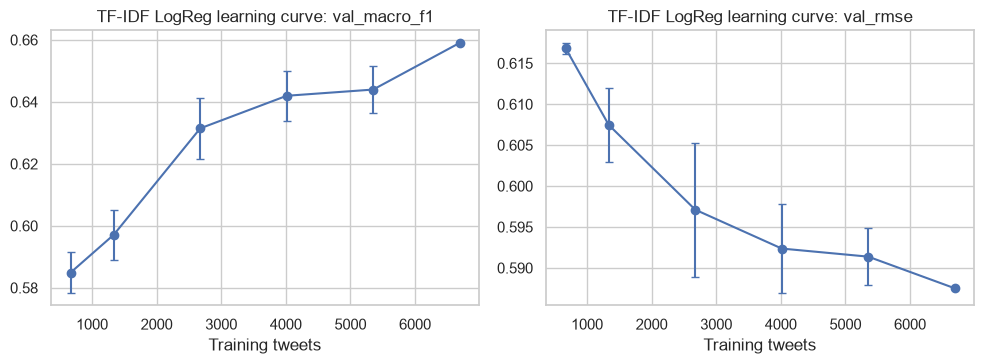

In [10]:
b5 = []
for frac in [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]:
    for seed in [0, 1, 2]:
        tr = train if frac == 1.0 else train.groupby("label", group_keys=False).sample(frac=frac, random_state=seed)
        f1, rmse, *_ = run("tfidf_logreg", best_lr["features"], logreg(best_lr["C"]), weight=best_weight,
                           tr=tr, log=False)
        b5.append(dict(frac=frac, n=len(tr), seed=seed, val_macro_f1=f1, val_rmse=rmse))
        if frac == 1.0:
            break
b5 = pd.DataFrame(b5).groupby(["frac", "n"])[["val_macro_f1", "val_rmse"]].agg(["mean", "std"]).reset_index()
display(b5.round(4))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, m in zip(axes, ["val_macro_f1", "val_rmse"]):
    ax.errorbar(b5["n"], b5[(m, "mean")], yerr=b5[(m, "std")].fillna(0), marker="o", capsize=3)
    ax.set_xlabel("Training tweets"); ax.set_title(f"TF-IDF LogReg learning curve: {m}")
plt.tight_layout(); plt.savefig(FIG + "b5_learning_curve_logreg.png", dpi=200); plt.show()

## Baseline 2: fastText
### F1: hyperparameter grid
Supervised fastText (softmax) on the cleaned text: averaged word (and optional bigram) embeddings with a linear classifier (Joulin et al., 2017).

*If `model.predict` raises a NumPy error ("Unable to avoid copy"), run `%pip install -q "numpy<2"` and restart the runtime.*

In [11]:
import fasttext

INV = {-1: "neg", 0: "neu", 1: "pos"}
NAME2 = {"__label__neg": -1, "__label__neu": 0, "__label__pos": 1}
CLASSES = np.array([-1, 0, 1])
FT_TRAIN = "data/processed/ft_train.txt"

with open(FT_TRAIN, "w", encoding="utf-8") as f:
    for t, y in zip(train["clean_text"], train["label"]):
        f.write(f"__label__{INV[y]} {t}\n")

def ft_predict(model, texts):
    labels, probs = model.predict(list(texts), k=3)
    P = np.zeros((len(labels), 3))
    for i, (ls, ps) in enumerate(zip(labels, probs)):
        for l, p in zip(ls, ps):
            P[i, NAME2[l] + 1] = p
    return CLASSES[P.argmax(1)], P @ CLASSES

def ft_train(**kw):
    return fasttext.train_supervised(FT_TRAIN, minCount=2, loss="softmax", verbose=0, seed=42, thread=1, **kw)

f1_grid = []
for lr, epoch, ng, dim in itertools.product([0.1, 0.5, 1.0], [10, 25], [1, 2], [50, 100]):
    m = ft_train(lr=lr, epoch=epoch, wordNgrams=ng, dim=dim)
    f1, rmse = score(val["label"], *ft_predict(m, val["clean_text"]))
    log_run("fasttext", dict(lr=lr, epoch=epoch, wordNgrams=ng, dim=dim, exp="F1"), f1, rmse, author=AUTHOR)
    f1_grid.append(dict(lr=lr, epoch=epoch, wordNgrams=ng, dim=dim, val_macro_f1=f1, val_rmse=rmse))
f1_grid = pd.DataFrame(f1_grid)
display(f1_grid.sort_values("val_macro_f1", ascending=False).head(8).round(4))
display(f1_grid.groupby("wordNgrams")[["val_macro_f1", "val_rmse"]].mean().round(4))
best_ft = f1_grid.loc[f1_grid["val_macro_f1"].idxmax()]
print("Best F1:", best_ft.to_dict())

,lr,epoch,wordNgrams,dim,val_macro_f1,val_rmse
6,0.1,25,2,50,0.6367,0.6046
10,0.5,10,2,50,0.6313,0.6227
11,0.5,10,2,100,0.6302,0.6229
7,0.1,25,2,100,0.6282,0.6043
22,1.0,25,2,50,0.6254,0.6441
15,0.5,25,2,100,0.6241,0.6343
14,0.5,25,2,50,0.6215,0.6317
2,0.1,10,2,50,0.6214,0.5785


,val_macro_f1,val_rmse
wordNgrams,,
1,0.5991,0.6644
2,0.6243,0.6216


Best F1: {'lr': 0.1, 'epoch': 25.0, 'wordNgrams': 2.0, 'dim': 50.0, 'val_macro_f1': 0.6367250214556316, 'val_rmse': 0.604648876116296}


### F2: training length
fastText exposes no per-epoch validation loss, so we retrain the best setting for increasing epoch counts to see under- and over-fitting.

*Interpretation:* fastText fits the training set perfectly by ~15-25 epochs (train macro-F1 1.00) while validation macro-F1 plateaus around 0.63 and validation RMSE is lowest at 10 epochs (0.579). The probabilities become over-confident with more epochs, which hurts RMSE more than F1.

,epoch,train_macro_f1,val_macro_f1,train_rmse,val_rmse
0,1,0.2171,0.2171,0.6761,0.6756
1,2,0.4532,0.4237,0.6425,0.6439
2,5,0.6648,0.5528,0.5395,0.5918
3,10,0.9340,0.6214,0.3260,0.5785
4,15,0.9972,0.6339,0.1481,0.5891
5,25,1.0000,0.6367,0.0428,0.6046
6,35,1.0000,0.6289,0.0216,0.6115
7,50,1.0000,0.6293,0.0115,0.6169


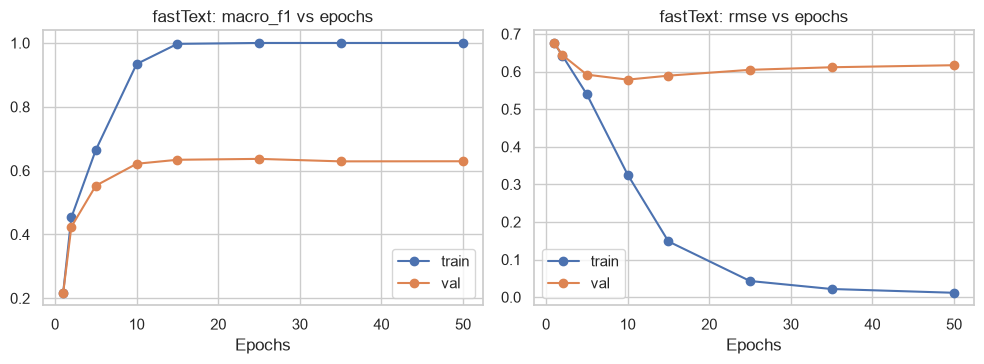

In [12]:
f2 = []
for ep in [1, 2, 5, 10, 15, 25, 35, 50]:
    m = ft_train(lr=best_ft["lr"], epoch=ep, wordNgrams=int(best_ft["wordNgrams"]), dim=int(best_ft["dim"]))
    tr_f1, tr_rmse = score(train["label"], *ft_predict(m, train["clean_text"]))
    va_f1, va_rmse = score(val["label"], *ft_predict(m, val["clean_text"]))
    f2.append(dict(epoch=ep, train_macro_f1=tr_f1, val_macro_f1=va_f1, train_rmse=tr_rmse, val_rmse=va_rmse))
f2 = pd.DataFrame(f2)
display(f2.round(4))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, m in zip(axes, ["macro_f1", "rmse"]):
    ax.plot(f2["epoch"], f2[f"train_{m}"], marker="o", label="train")
    ax.plot(f2["epoch"], f2[f"val_{m}"], marker="o", label="val")
    ax.set_xlabel("Epochs"); ax.set_title(f"fastText: {m} vs epochs"); ax.legend()
plt.tight_layout(); plt.savefig(FIG + "f2_fasttext_epochs.png", dpi=200); plt.show()

== fasttext | RMSE 0.6161 ==
              precision    recall  f1-score   support

    negative      0.469     0.250     0.326       152
     neutral      0.769     0.798     0.783       693
    positive      0.680     0.732     0.705       589

    accuracy                          0.713      1434
   macro avg      0.639     0.593     0.605      1434
weighted avg      0.701     0.713     0.703      1434



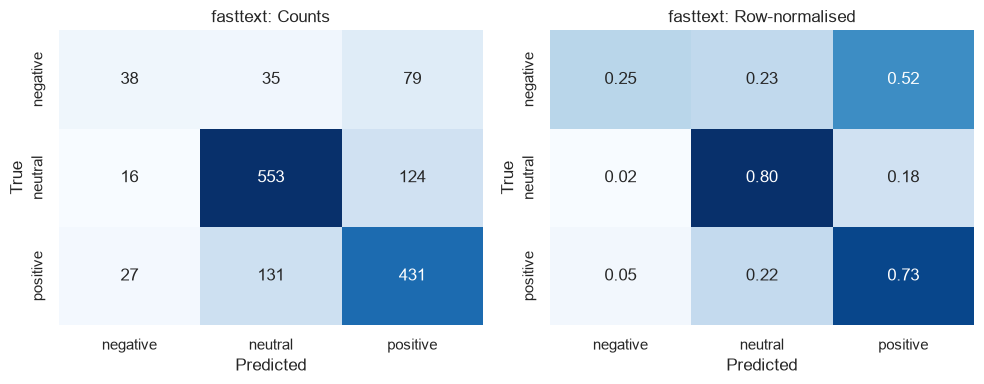

In [13]:
m_ft = ft_train(lr=best_ft["lr"], epoch=int(best_ft["epoch"]), wordNgrams=int(best_ft["wordNgrams"]), dim=int(best_ft["dim"]))
yp, ys = ft_predict(m_ft, test["clean_text"])
evaluate(test["label"], yp, "fasttext", y_score=ys)
save_predictions("fasttext", test["tweet_id"], test["safe_text"], test["label"], yp, test["agreement"], ys)

## Results so far and experiment log

**Summary.** TF-IDF + Logistic Regression is the strongest baseline on both metrics (test macro-F1 0.655, RMSE 0.584). fastText is close on neutral and positive tweets but its negative-class F1 is only 0.33, because its supervised mode has no class weighting and its averaged embeddings cannot weight rare negative cues. Word bigrams helped fastText (+0.025 mean macro-F1), and character n-grams helped TF-IDF, which shows that some local word order and sub-word information matter. Negative tweets are the hardest class for every baseline, which is consistent with the EDA: they are the smallest class, have the lowest annotator agreement (0.71), and share their vocabulary with positive tweets.

In [14]:
display(pd.read_csv("reports/results.csv"))
log = pd.read_csv("reports/experiment_log.csv")
print(len(log), "runs logged")
display(log.tail(10))

,model,rmse,macro_f1,accuracy,weighted_f1,f1_negative,f1_neutral,f1_positive
0,tfidf_logreg,0.5838,0.6551,0.7183,0.7233,0.4638,0.7916,0.7098
1,tfidf_ridge,0.5844,0.5139,0.6444,0.6188,0.2162,0.7091,0.6163
2,fasttext,0.6161,0.6048,0.7127,0.7026,0.3262,0.7833,0.7048


92 runs logged


,timestamp,author,model,params,val_macro_f1,val_rmse,notes
82,2026-09-29 00:19,P1,fasttext,"{""lr"": 0.5, ""epoch"": 25, ""wordNgrams"": 2, ""dim...",0.6215,0.6317,NaN
83,2026-09-29 00:19,P1,fasttext,"{""lr"": 0.5, ""epoch"": 25, ""wordNgrams"": 2, ""dim...",0.6241,0.6343,NaN
84,2026-09-29 00:19,P1,fasttext,"{""lr"": 1.0, ""epoch"": 10, ""wordNgrams"": 1, ""dim...",0.6015,0.6626,NaN
85,2026-09-29 00:19,P1,fasttext,"{""lr"": 1.0, ""epoch"": 10, ""wordNgrams"": 1, ""dim...",0.6041,0.6627,NaN
86,2026-09-29 00:19,P1,fasttext,"{""lr"": 1.0, ""epoch"": 10, ""wordNgrams"": 2, ""dim...",0.6183,0.6431,NaN
87,2026-09-29 00:19,P1,fasttext,"{""lr"": 1.0, ""epoch"": 10, ""wordNgrams"": 2, ""dim...",0.6143,0.6449,NaN
88,2026-09-29 00:19,P1,fasttext,"{""lr"": 1.0, ""epoch"": 25, ""wordNgrams"": 1, ""dim...",0.5756,0.7160,NaN
89,2026-09-29 00:19,P1,fasttext,"{""lr"": 1.0, ""epoch"": 25, ""wordNgrams"": 1, ""dim...",0.5750,0.7141,NaN
90,2026-09-29 00:19,P1,fasttext,"{""lr"": 1.0, ""epoch"": 25, ""wordNgrams"": 2, ""dim...",0.6254,0.6441,NaN
91,2026-09-29 00:19,P1,fasttext,"{""lr"": 1.0, ""epoch"": 25, ""wordNgrams"": 2, ""dim...",0.6201,0.6503,NaN
